## Tool Schemas Claude Selects Correctly: Definition, Loop, and Calling Patterns


- Claude reads the tool definitions,
- Decides which one fits the situations
- Tell your app what to call it along with the required input.


#### Proper Implementation:
1. **Define Schema**:
    - name
    - Description
    - Input Schema

2. **Send Message** : your code sends a message to claude including the tool definition adn the users input

3. **tool_use Block** :
    - Claude issues a tool_use block with:
        - tool name
        - a Unique ID
        - The input arguments
    The API response comes back with 'stop_reason : tool_use'

4. **Execute tool** : Your code executes the tool using those arguments.
    - Note that the assistant turn has already ended (Claude is not holding a connection open or waiting on your server).
    - The model is stateless between calls.
    - To continue, your code makes a fresh API request containing the prior messages plus the tool result.

5. **Return result** : You return the result in a 'tool_result' block that references the original 'tool_use' ID.

6. **Claude Continues** : Claude continues using the tool result as context for its next response, either another toll-block     or a final end turn


### Message block structure in a tool-use conversation

- Structured Blocks
- Assistant turn and User turn
- 4 block types for tool_use session
    - text_block : Claude's prose response
    - tool_use block : tool call (tool name, unique ID and input arguments)
    - tool_result block : code return after running the tool
    - thinking block : internal reasoning (when extended thinking is enabled)

Note: Every tool_use block in an assistant turn must be answered by tool_result block with a matching ID in the user turn that immediately follows.
- If:
    - IDs dont match
    - result is missing
    - turns are out of order

The request fails validation (Prompt adjustment won't work)

**_Text Block_**
- _Role_: Assistant/Claude
- _Contains_: Claude’s prose output
- _Critical Rule_ :
-     - Claude can return a text block with a tool_use block in the same turn.
      - your code must preserve the full content array (along with text block,when appending that turn to
      - conversation history. otherwise it corrupts the context

**_tool_use block_**
- _Role_ : Assistant/Claude
- _Contains_ : tool name, unique ID, input argument
- _Critical Rule_ : Every tool_use block must be answered by a tool_result block in the immediately following user turn with same ID

**_tool_result Block_**
- _Role_ : User
- _Contains_ :
        - Matching tool_use ID,
        - the result content and
        - is_error flag (true)
- _Critical Rule_ :
-     - The tool_use_id value must match the original tool_use block exactly.
      - Claude uses this ID to connect each result back to the call that produced it,
      - which matters when a single assistant turn issues multiple tool calls and the results arrive in a different order.

**_thinking Block_**
- _Role_ : Assistant (extended thinking only)/Claude
- _Contains_ : Claude's internal reasoning, only visible when enabled
- _Critical Rule_ : The block must be passed back to the api unchanged in subsequent turns.

### Schema anatomy: What Claude reads to make a tool selection decision
1. **Name**: A short identifier that should be specific. For example, get_account_balance is more useful to Claude than get_data.
2. **Description**: A critical part that Claude reads to decide whether a tool is required or not. You should always write the description in two parts, including when to and when not to use the tool:
    - A description that says "use this to find information" will cause wrong selections because Claude cannot distinguish it from any other tool that retrieves something.
    - A description that says "use this to retrieve the current balance for a specific account ID and do not use this for transaction history" gives Claude an exclusion condition to work with and is appropriately descriptive.
3. **input_schema**: Defines the parameters (the inputs your tool function accepts) using JSON Schema.
    - You should mark parameters as required when Claude requires them to call the tool correctly.
    - You can mark parameters as optional when the tool can operate without them. Overlapping parameter types between tools is the most common source of wrong-tool calls.

### Decision table: Schema design choices

**Subtask Dependency**: Sequential dependency requires multiple turns; independent tools run in parallel by default (use disable_parallel_tool_use to override).

**Required vs. Optional**: Only mark fields as required if the call breaks without them; leave optional fields out of the required array.

**Description Length**: Aim for 3–4 sentences covering function, triggers, return values, and valid input formats.

**Disambiguation**: Add domain-specific exclusion boundaries when two tools share similar parameter shapes.

**Merging Tools**: If two tools require extensive descriptions to differentiate, merge them into a single tool with a type parameter.

### Model Context Protocol (MCP) Integration

**Purpose**: A standardized protocol to offload tool definition and execution to dedicated MCP servers.

**Setup Flow**: Client sends a ListToolsRequest to the MCP server to dynamically register schemas into Claude's context.

**Transport Modes**:

_stdio_: Used for local subprocesses (managed directly via SDK).

_Streamable HTTP_: Used for remote network servers (supported via standard API connectors).

**Context Optimization**:

_defer_loading_: Delays loading schema details into context until needed.

_enabled_: Toggles specific server tools on/off to manage token overhead.

_Header_: Requires mcp-client-2025-11-20 beta header for API connector feature support.

## Streaming Response

**1. What Streaming Changes**:

**Mechanics**: Sends incremental events as the model generates text, reducing perceived latency instead of waiting for a single complete payload.

C**lient Responsibility**: Application code must assemble events into content blocks and handle mid-stream interruptions manually.

**Stateless Model**: The model does not maintain an open state; it emits individual event signals describing block start, delta updates, and block completion.

**2. Streaming Event Sequence**

**message_start**: Initializes the message shell; client sets up an empty content array.

**content_block_start**: Opens a block at a specific index (text, tool_use, or thinking).

**content_block_delta**: Carries incremental text fragments or partial JSON string updates for tool calls.

**content_block_stop**: Signals block completion; JSON parameters for tool calls become fully valid and safe to parse only at this step.

**message_delta**: Updates top-level metadata (such as stop_reason and final token usage counts).

**message_stop**: Marks complete stream transmission; assembled content can now be safely committed to history.

**3. State Protection & Partial Blocks**

**Rule for tool_use**: Never attempt to parse or execute tool parameters during content_block_delta events, as partial JSON string fragments are incomplete.

**Conversation History**: Add the turn to conversation history only after _message_stop_ confirms all blocks are complete to prevent history corruption.

**4. Handling Interrupted Streams**

**Provisional State**: Treat accumulated stream events as provisional until message_stop is received.

**Cleanup on Error**: If a stream drops or times out mid-way, throw away the incomplete assistant turn entirely and retry the request rather than saving a partial block.

**Flow Control**: Always check stop_reason from message_delta before executing downstream tasks (e.g., ensure stop_reason == "tool_use" before triggering tool execution).

**5. Trade-offs & Recommendations**

**Best Used For**: Long text outputs and user-facing UIs where streaming improves interactive response times.

**Avoid Using For**: Backend automated tasks, short non-interactive responses, or logic where non-streamed requests eliminate partial-state edge cases completely.

Here is a Python code snippet using the Anthropic SDK (anthropic) that demonstrates the exact logic and rules explained on the Production-Grade Prompting, Agents & Tool Use page:

**Event Handling**: Sets up initial message state on message_start and tracks content blocks (text, tool_use, thinking).

**Safe Delta Accumulation**: Collects raw JSON input fragments into memory without attempting to parse them prematurely.

**Block Completion Validation**: Only parses tool_use parameters inside the content_block_stop handler.

P**rovisional State Protection**: Only commits the final turn to conversation history if message_stop completes successfully without network interruptions or errors.

In [ ]:
import json
import anthropic

client = anthropic.Anthropic()

conversation_history = [
    {"role": "user", "content": "What's the weather in San Francisco?"}
]

tools_schema = [
    {
        "name": "get_weather",
        "description": "Get current weather for a location.",
        "input_schema": {
            "type": "object",
            "properties": {"location": {"type": "string"}},
            "required": ["location"],
        },
    }
]


def process_stream_safely(history, tools):
    # Temporary variables to track provisional state during streaming
    assembled_blocks = {}
    stop_reason = None
    stream_completed_successfully = False

    try:
        with client.messages.stream(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1024,
            tools=tools,
            messages=history,
        ) as stream:
            for event in stream:

                # 1. message_start: Initialize response container
                if event.type == "message_start":
                    assembled_blocks = {}

                # 2. content_block_start: Create slot for block type
                elif event.type == "content_block_start":
                    index = event.index
                    block_type = event.content_block.type

                    if block_type == "text":
                        assembled_blocks[index] = {"type": "text", "text": ""}
                    elif block_type == "tool_use":
                        assembled_blocks[index] = {
                            "type": "tool_use",
                            "id": event.content_block.id,
                            "name": event.content_block.name,
                            "raw_json": "",  # Store JSON fragment here, do not parse yet!
                        }

                # 3. content_block_delta: Append text/JSON deltas
                elif event.type == "content_block_delta":
                    index = event.index
                    delta = event.delta

                    if delta.type == "text_delta":
                        assembled_blocks[index]["text"] += delta.text
                        print(delta.text, end="", flush=True)
                    elif delta.type == "input_json_delta":
                        # Accumulate string fragments; DO NOT call json.loads here
                        assembled_blocks[index]["raw_json"] += delta.partial_json

                # 4. content_block_stop: Safe point to parse tool input
                elif event.type == "content_block_stop":
                    index = event.index
                    block = assembled_blocks[index]

                    if block["type"] == "tool_use":
                        # Safe to parse JSON parameters now that block is closed
                        block["input"] = json.loads(block["raw_json"])
                        del block["raw_json"]  # Clean up internal tracking field

                # 5. message_delta: Capture top-level metadata like stop_reason
                elif event.type == "message_delta":
                    stop_reason = event.delta.stop_reason

                # 6. message_stop: Mark payload complete
                elif event.type == "message_stop":
                    stream_completed_successfully = True

    except Exception as e:
        print(f"\nStream interrupted or failed: {e}")
        # THROW AWAY provisional state; do not pollute history with incomplete turns
        return None

    # Handle completion vs state protection
    if stream_completed_successfully:
        final_content_blocks = list(assembled_blocks.values())

        # Only append turn to history once message_stop confirms full assembly
        history.append({"role": "assistant", "content": final_content_blocks})

        # Check stop_reason before executing downstream actions
        if stop_reason == "tool_use":
            print("\nStream finished safely. Tool calls ready for execution.")
            # Execute tool logic here...
        else:
            print("\nStream finished safely. Standard response complete.")

        return final_content_blocks
    else:
        print("\nStream ended abruptly. discarding partial output.")
        return None


# Run the stream handler
process_stream_safely(conversation_history, tools_schema)

### Agent Construction

**1. Choosing the Pattern: Workflow vs. Agent**

Before writing code, decide whether the task genuinely requires an agent.

_Use a Workflow when:_

- Steps can be enumerated explicitly in code with fixed, predictable sequences.

- Inputs are constrained to a known set and error cost requires step-level guardrails.

- Deterministic execution and standard operational observability are required.

_Use an Agent when:_

- Only the goal and available tools are specified, but the path cannot be enumerated in advance.

- User inputs vary unpredictably in structure or content.

- The task demands non-deterministic, creative sequencing of registered tools.



**2. Choosing a Wiring Path**

An agent pattern remains constant (a loop executing tools based on context), but the wiring path dictates how much execution infrastructure you manage versus delegate:

- Raw Messages API Loop: You write every iteration, parse tool_use blocks, invoke functions, append tool_result payloads, and maintain history manually. Ideal for complete control or learning core mechanics.

- Agent SDK: Runs inside your application process; abstracts loop management, context retention, and parallel tool handling while you provide tool implementations.

- Claude Managed Agents (Public Beta): Anthropic manages the loop, long-running session state, and execution sandbox server-side. Your application registers the agent as an API resource, sends events, and consumes SSE streams.

    - Regulatory Constraint: Stateful server-side storage in Managed Agents currently makes them ineligible for Zero Data Retention (ZDR) or HIPAA Business Associate Agreements (BAA). Regulated workloads carrying PHI must use the Agent SDK or a Raw Loop on a compliant deployment.



**3. Core Loop Steps & Verification Checklist**

Regardless of the wiring path, every production agent loop must maintain four core steps:

- Register Tools: Define tools using explicit schemas. Avoid registering unnecessary tools ("over-tooling"), as excessive tool sets degrade routing performance.

- Set System Prompt: Keep system instructions scoped tightly to the active task and available tools.

- Handle Tool Execution: Ensure every tool_use block emitted by an assistant turn is resolved with a corresponding tool_result before the next turn.

- Define Exit Conditions: Set explicit, programmatic stopping criteria rather than relying on the model to volunteer to stop.

**4. Human-in-the-Loop (HITL) Checkpoints**

Insert human review steps based on failure severity:

- Before Destructive Tool Calls: Prevent irreversible actions (e.g., database writes, external communication, or file deletions).

- After Planning Steps: Validate agent-generated plans before allowing multi-step execution.

- On Unexpected Output: Intercept tool errors or outputs outside expected boundary values where automated retries are insufficient.



**5. Regulated Data & Deployment Constraints**

Compliance requirements determine your deployment route, client configuration, and logging architecture prior to prompt design:

- Attorney-Client Privilege / Proprietary Data: Avoid consumer-grade surfaces. Use direct API/SDK calls integrated with SSO and an enterprise-approved gateway that captures required application-level logs.

- HIPAA / PHI Compliance: Target designated BAA-covered API environments or cloud-mediated routes (such as AWS Bedrock or GCP Vertex) where feature restrictions and retention policies are bound by contract.

### Agent Memory

**1. Overview of Memory Scope**

Memory scope determines what state an agent retains between sessions and the associated cost of carrying that knowledge forward. Selecting the wrong memory strategy during the design phase leads to two main failure modes:

- _Over-retaining state in-context_: Causes token usage and costs to scale rapidly with session length, as the entire conversation history must be re-sent on every turn.

- _Under-retaining state_: Strips the agent of necessary context when the session ends, forcing users to re-provide information.

**2. Breakdown of Memory Scopes & Trade-offs**

**In-Context Memory:**

- What persists: State lives in the active conversation and survives turns within a single session.

- Cost & Mechanics: Zero retrieval overhead, but token costs grow continuously with conversation length.

- Best Used For: Short sessions where all required context fits in the window and state persistence across restarts is unnecessary.

- Drawback: Wiped completely when a session ends or context is cleared.

**External Storage:**

- What persists: State is written to an external database and loaded at session start or on demand.

- Cost & Mechanics: Incurs database retrieval latency and requires engineering read/write logic, but eliminates context window inflation.

- Best Used For: Multi-day threads, multi-user state sharing, or cross-instance persistence.

- Drawback: Adds system implementation complexity and per-turn query latency.

**Summarized Memory:**

- What persists: A compressed version of previous interactions is generated and injected into new sessions.

- Cost & Mechanics: Lower token cost than replaying raw history, but requires a summarization step.

- Best Used For: Long-running conversational agents where raw history would exceed token budgets.

- Drawback: Fine details not captured by the summarizer prompt are permanently lost.

**Stateless (No Persistent Memory):**

- What persists: Nothing; every session is isolated.

- Cost & Mechanics: Zero memory-related token or latency overhead.

- Best Used For: One-off task-execution pipelines and independent batch processing.

**3. Design-Time Decision Making**

Deciding how an agent handles memory should happen during initial architecture design rather than as a production refactor:

- Prototyping by dumping the entire conversation into the messages array works initially, but leads to high latency, high costs, and context window limits in production.

- Refactoring later requires restructuring memory pipelines and database logic under timeline pressure.

**4. On-Demand Skills vs. Always-On Instructions**

To carry repeatable instructions across tasks without inflating context windows:

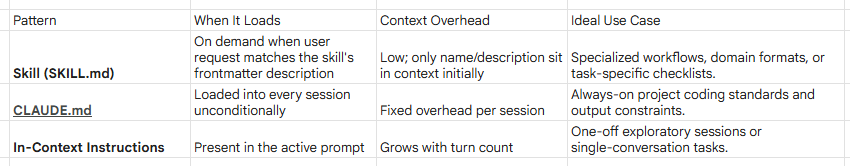

**5. Messages API Integration & Subagent Constraints**

- _Beta Configuration_: On the Messages API, Skills require specific beta headers (code-execution-2025-08-25 and skills-2025-10-02) and run inside a containerized execution environment.

- _Subagent Inheritance_: Subagents do not automatically inherit Skills or conversation history from parent sessions, though they do inherit permission scopes. Skills must be explicitly configured on subagents when delegating tasks.

## Multimodal and Batch Ingestion

**1. Image Token Cost & Calculation**

_Visual Token Formula_: Claude processes images in 28 * 28 pixel patches. Cost is calculated as:

$$\lceil \text{width} / 28 \rceil \times \lceil \text{height} / 28 \rceil$$(e.g., a $1,000 \times 1,000$ image consumes about 1,296 visual tokens).

- Downscaling & Native Limits: Images exceeding model resolution or token limits are automatically downscaled before tokenization.

- Design Precaution: Calculate image token overhead at design time; a simple image resize step can prevent pipeline context window overruns.

**2. Image & PDF Ingestion Methods**

_Ingestion Options_: Images and PDFs can be sent via base64 encoding, URL references, or the Files API (file_id).

_PDFs (document block)_: PDF blocks use type: "document" and accept optional title and context fields.

_Files API Advantage_: Uploads the asset once to reference in future requests, drastically reducing payload overhead across multi-turn sessions.

**3. Multimodal Prompting**

Managing Visual Ambiguity: Image prompts require explicit constraints to address ambiguities like overlapping objects, depth, or occlusion (e.g., instructing Claude on how to handle partially hidden objects).

**4. Message Batches API**

- Capacity & Efficiency: Processes up to 100,000 requests or 256 MB per batch call asynchronously at a lower per-token cost.

- Latency Tradeoff: Takes up to 24 hours to complete; best suited for offline processing, evaluations, or nightly pipelines rather than real-time interactive user flows.

5. Key Tradeoffs & Best Practices

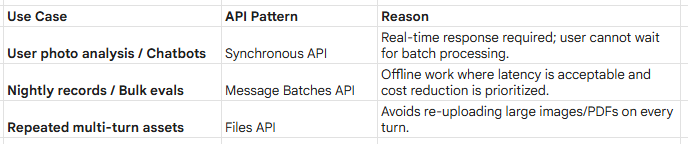